In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Organize the results in a DataFrame
df_simulation = pd.read_csv("datos_prueba.csv", sep=";")
df_simulation['Time'] = 1
df_simulation['x1'] = df_simulation['x1'].str.replace(',', '.').astype(float)
df_simulation['x2'] = df_simulation['x2'].str.replace(',', '.').astype(float)

In [3]:
df_simulation.head()

,y,x1,x2,Time
0,0,-0.930064,-1.064841,1
1,3,-0.998695,0.261597,1
2,1,-0.761095,0.503711,1
3,1,-0.681206,0.911498,1
4,0,0.722834,0.773865,1


In [4]:
# Calculate the esteemed lambda
total_events = df_simulation['y'].sum()
total_time = df_simulation['Time'].sum()

rec_lambda = total_events / total_time

print(f"Recovered Lambda: {rec_lambda:.4f}")

Recovered Lambda: 1.3700


In [5]:
import statsmodels.api as sm

# El logaritmo del tiempo actúa como 'offset' en una regresión de Poisson
df_simulation['log_time'] = np.log(df_simulation['Time'])

# Ajustar el modelo
modelo = sm.GLM(df_simulation['y'], 
                np.ones(len(df_simulation)), # Solo intercepto
                family=sm.families.Poisson(),
                offset=df_simulation['log_time']).fit()

# El valor recuperado es exp(intercepto)
lambda_glm = np.exp(modelo.params[0])
print(f"Recovered Lambda from GLM: {lambda_glm:.4f}")

Recovered Lambda from GLM: 1.3700


C:\Users\Athan\AppData\Local\Temp\ipykernel_35128\1955229590.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda_glm = np.exp(modelo.params[0])


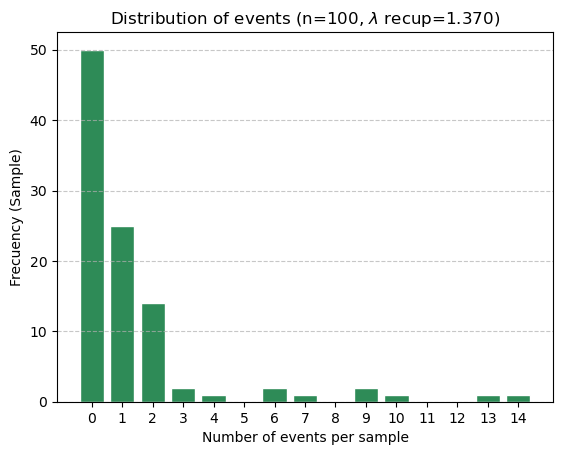

In [6]:
# Histograma de eventos observados
plt.hist(df_simulation['y'], bins=np.arange(df_simulation['y'].max() + 2) - 0.5, 
         color='seagreen', edgecolor='white', rwidth=0.8)

plt.title(f'Distribution of events (n=100, $\lambda$ recup={rec_lambda:.3f})')
plt.xlabel('Number of events per sample')
plt.ylabel('Frecuency (Sample)')
plt.xticks(range(df_simulation['y'].max() + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 3. Establecer el valor de lambda (tasa de eventos por unidad de tiempo)
lam = 0.0876

# 4. Simular el número de eventos para cada paciente
# La media de la distribución de Poisson para cada paciente es lambda * t_i
eventos = np.random.poisson(lam)

# Histograma de eventos observados
plt.hist(eventos, bins=np.arange(eventos.max() + 2) - 0.5, 
         color='seagreen', edgecolor='white', rwidth=0.8)

plt.title(f'Distribución de Eventos (n={n}, $\lambda$ recup={lambda_recuperado:.3f})')
plt.xlabel('Número de Eventos por Paciente')
plt.ylabel('Frecuencia (Pacientes)')
plt.xticks(range(eventos.max() + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)

In [9]:
X1 = df_simulation['x1']
X2 = df_simulation['x2']
print("X1 type:", X1.dtype)
print("X2 type:", X2.dtype)
print("Tipo de X1:", X1.dtype)
print("Tipo de X2:", X2.dtype)
# 3. Establecer los Betas reales (Valores que queremos recuperar)
beta0 = 0.01 # Intercepto (Equivale a una tasa base de ~0.095)
beta2 = 0   # Efecto de X2 (Aumenta el riesgo)
beta1 = 1  # Efecto de X1 (Disminuye el riesgo)

# 4. Calcular Lambda individual usando la función de enlace logarítmica
# log(lambda) = beta0 + beta1*X1 + beta2*X2
log_lambda = beta0 + beta2*X2 + beta1*X1 
lambda_i = np.exp(log_lambda)

# 5. Simular tiempos de seguimiento (t_i) entre 0.5 y 5 años
times = df_simulation['Time']

# 6. Simular número de eventos: Poisson(lambda_i * t_i)
events = df_simulation['y']

# --- RECUPERACIÓN DE BETAS CON UN GLM (Modelo Lineal Generalizado) ---

# Definir variables independientes (añadiendo el intercepto)
X_model = sm.add_constant(df_simulation[['x1', 'x2']])

# Ajustar Modelo de Poisson
# El offset es vital porque: log(E[y]) = log(lambda * t) = log(lambda) + log(t)
modelo_glm = sm.GLM(df_simulation['y'], X_model, 
                    family=sm.families.Poisson(), 
                    offset=df_simulation['log_time']).fit()

# --- COMPARACIÓN DE RESULTADOS ---
resultados = pd.DataFrame({
    'Beta_Real': [beta0, beta1, beta2],
    'Beta_Recuperado': modelo_glm.params.values,
    'Error_Estandar': modelo_glm.bse.values
}, index=['Intercepto', 'X1', 'X2'])

print("--- RESULTADOS DE LA RECUPERACIÓN ---")
print(resultados)
print("\n" + "="*30)
print("Resumen estadístico detallado:")
print(modelo_glm.summary())

X1 type: float64
X2 type: float64
Tipo de X1: float64
Tipo de X2: float64
--- RESULTADOS DE LA RECUPERACIÓN ---
            Beta_Real  Beta_Recuperado  Error_Estandar
Intercepto       0.01        -0.089095        0.117132
X1               1.00         1.021021        0.089802
X2               0.00        -0.237255        0.084764

Resumen estadístico detallado:
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  100
Model:                            GLM   Df Residuals:                       97
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -151.50
Date:                Tue, 16 Jun 2026   Deviance:                       174.87
Time:                        14:03:13   Pearson chi2:                     190.
No. 